# General information
<span style="color: green"> **Please use the BIDS structure**</span> so that pipeline can run smoothly. Place ipynb-notebooks on the top level of the project folder (same level as subject folders).


**Gereral processing steps:**  
0. [Import libraries](#0-import-libraries)  
1. [Set channel types and montage](#1-set-channel-types-montage)    
2. [Filter (1-40 Hz)](#2-filter)  
3. [Restoring Reference channel](#3-restoring-reference-channel-and-average-reference)  
4. [Save filter and re-referenced data](#4-save-filtered-and-re-referenced-files)  
5. [Reject and Interpolate channels](#5-rejection-and-interpolation-of-channels)  
6. [Artifact Subspace Reconstruction](#6-artifact-subspace-reconstruction)  
7. [Epoching](#7-epoching)  
8. [Adaptive mixture independent component analysis (AMICA)](#8-adaptive-mixture-independent-component-analysis)  
9. [AMICA Rejection](#9-amica-rejection)  

::: {#eeg-process}

![](Fig2-EEGProcess.svg){width=80%}

EEG processing overview

:::

# 0. Import libraries

The analysis pipeline is based on the following libraries. In case of an error in the execution of this cell, probably one or more of the libraries is not installed. In this case, start a terminal in **ANACONDA.NAVIGATOR** *Environments>Terminal* and install the library in question using the command <span style='color: red'>*pip install [library name]*</span>.

In [ ]:
import warnings                 # switch of pandas and mne warnings
warnings.simplefilter(action='ignore')

import requests
import os
import os.path as op
import time
from pathlib import Path

import mne

import gc
import numpy as np
import pandas as pd
import ipyfilechooser
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import pyprep
from pyprep.prep_pipeline import PrepPipeline
from datetime import datetime, timedelta
from datetime import datetime, timezone
#from playsound import playsound
from openpyxl import load_workbook
from mne.export import export_raw

from collections import defaultdict
from mne.datasets import fetch_fsaverage
from mne.evoked import combine_evoked
from mne.forward import make_forward_dipole
from mne.simulation import simulate_evoked
from mne.viz import circular_layout
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle
from mne_icalabel import label_components
from mne_icalabel.gui import label_ica_components
#from asrpy import ASR
from meegkit.asr import ASR

from nilearn.image import index_img
from nilearn.plotting import plot_stat_map
from mne import read_evokeds
from mne.datasets import sample
from mne.minimum_norm import  make_inverse_operator, apply_inverse, read_inverse_operator, apply_inverse_epochs

%matplotlib qt

mne.set_log_level("ERROR")  # only show errors (no warnings or information messages)

# 1. Set channel types, montage

## 1.1. Load files 
Find and load the concatenated eeg files for further processing.

In [10]:
wd = Path.cwd()
CONCAT_RAW_PATH = wd / "derivatives" / "02_poc_concat_raw"

# -------------------------------------------------------------------------
# LOAD CONCATENATED RAW FILES
# Discovers all .fif files under 02_poc_concat_raw/sub-XX/ses-XX/eeg/
# -------------------------------------------------------------------------
raw_files = sorted(CONCAT_RAW_PATH.rglob("*desc-concat_eeg.fif"))
print(f"Found {len(raw_files)} concatenated raw files")

eegConcat = []

for fif_file in raw_files:
    ses_name = fif_file.parent.parent.name
    sub_name = fif_file.parent.parent.parent.name

    try:
        raw = mne.io.read_raw_fif(fif_file, preload=True)
        eegConcat.append(raw)
        print(f"Loaded : {sub_name} / {ses_name}")

    except Exception as e:
        print(f"Error loading {sub_name} / {ses_name} : {e}")

Found 2 concatenated raw files
Loaded : sub-01 / ses-01
Loaded : sub-02 / ses-01


## 1.2. Set channel types and montage

In [11]:
# -------------------------------------------------------------------------
# SET CHANNEL TYPES AND MONTAGE
# Applied to all concatenated raw files.
# Channel types distinguish EEG from EOG, EMG, and acceleration sensor channels.
# EasyCap M1 montage provides standard electrode locations.
# -------------------------------------------------------------------------

for raw in eegConcat:
    # Set non-EEG channel types
    raw.set_channel_types({
        "HEOG"   : "eog",
        "VEOG"   : "eog",
        "NeckEMG": "emg",
        "x_dir"  : "misc",
        "y_dir"  : "misc",
        "z_dir"  : "misc",
    })

    # Apply standard EasyCap M1 montage for electrode locations
    raw.set_montage(mne.channels.make_standard_montage("easycap-M1"))

print(f"Channel types and montage set for {len(eegConcat)} files")

Channel types and montage set for 2 files


# 2. Filter

Originally, we used a 1 Hz to 40 Hz band-pass filter.
For future analyses, use only 1 Hz high-pass filter. Then apply 40 Hz low-pass at the end of the source-space processing (after AMICA).

In [ ]:
# -------------------------------------------------------------------------
# BANDPASS FILTER
# Current study: 1–40 Hz bandpass.
# Note: for future studies a 1 Hz high-pass only is recommended,
# leaving the low-pass to be applied after all other 
# source-space processing (after AMICA if needed).
# To switch, set h_freq=None.
# -------------------------------------------------------------------------
L_FREQ = 1    # high-pass cutoff (Hz)
H_FREQ = 40   # low-pass cutoff (Hz) — set to None for high-pass only

for raw in eegConcat:
    raw.filter(l_freq=L_FREQ, h_freq=H_FREQ)
    print(f"Filtered : {Path(raw.filenames[0]).name}")

print(f"\nFilter applied : {L_FREQ}–{H_FREQ} Hz" if H_FREQ else f"\nHigh-pass filter applied : {L_FREQ} Hz")

Filtered : sub-01_ses-01_task-sidecut_desc-concat_eeg.fif
Filtered : sub-02_ses-01_task-sidecut_desc-concat_eeg.fif

High-pass filter applied : 1 Hz


# 3. Restoring reference channel and average reference

Restore reference-channel (FCz) as zero-channel. Then, use average reference.

Finally, safe filtered EEG files before pyPREP and ASR.

In [13]:
# -------------------------------------------------------------------------
# FUNCTION: add_ref
# Adds FCz back as a zero channel (online recording reference) and
# re-references to average. The montage is re-applied after adding FCz
# since adding a new channel resets electrode locations.
#
# Parameters
# ----------
# raw : mne.io.Raw — filtered raw EEG data without FCz
#
# Returns
# -------
# raw : mne.io.Raw — re-referenced raw EEG data with FCz restored
# -------------------------------------------------------------------------
def add_ref(raw):
    if "FCz" not in raw.ch_names:
        raw = mne.add_reference_channels(raw, ref_channels=["FCz"])
    else:
        print("FCz already present, skipping")

    raw.set_montage(mne.channels.make_standard_montage("easycap-M1"))
    raw.set_eeg_reference("average", projection=False)
    return raw

In [14]:
# -------------------------------------------------------------------------
# APPLY REFERENCE TO ALL FILES
# -------------------------------------------------------------------------
eegConcat = [add_ref(raw) for raw in eegConcat]
print(f"FCz added and average reference applied to {len(eegConcat)} files")

FCz added and average reference applied to 2 files


# 4. Save filtered and re-referenced files

In [16]:
# -------------------------------------------------------------------------
# SAVE FILTERED AND RE-REFERENCED FILES
# Output: derivatives/03_poc_filt_ref/sub-XX/ses-XX/eeg/
#         sub-XX_ses-XX_task-sidecut_desc-filtref_eeg.fif
# -------------------------------------------------------------------------
FILT_REF_PATH = wd / "derivatives" / "03_poc_filt_ref"

for raw in eegConcat:
    fif_path = Path(raw.filenames[0])
    ses_name = fif_path.parent.parent.name
    sub_name = fif_path.parent.parent.parent.name

    output_dir = FILT_REF_PATH / sub_name / ses_name / "eeg"
    output_dir.mkdir(parents=True, exist_ok=True)

    output_name = fif_path.name.replace("_desc-concat_", "_desc-filtref_")
    output_path = output_dir / output_name

    raw.save(output_path, overwrite=True)
    print(f"Saved : {sub_name} / {ses_name} / {output_name}")

print(f"\nSaved {len(eegConcat)} files to {FILT_REF_PATH}")

Saved : sub-01 / ses-01 / sub-01_ses-01_task-sidecut_desc-filtref_eeg.fif
Saved : sub-02 / ses-01 / sub-02_ses-01_task-sidecut_desc-filtref_eeg.fif

Saved 2 files to /home/joel/Documents/BIDS - Kopie/CoMoCut_Proof-of-conept/derivatives/03_filt-ref


# 5. Rejection and interpolation of channels

Rejecting and interpolating channels together with robust referencing with the pyPREP pipeline [@Bigdely-Shamlo2015; @appelhoffPyPREPPythonImplementation2023].

Link:  
[https://github.com/sappelhoff/pyprep](https://github.com/sappelhoff/pyprep)  



In [6]:
# -------------------------------------------------------------------------
# PYPREP PIPELINE
# Runs the PREP pipeline (robust re-referencing, bad channel detection and
# interpolation via RANSAC) on each filtered and re-referenced file.
# Files are loaded from disk one at a time and explicitly freed after saving
# to minimize memory usage.
# Output: derivatives/04_poc_pyprep/sub-XX/ses-XX/eeg/
# -------------------------------------------------------------------------
wd = Path.cwd()
FILTER_REF_PATH = wd / "derivatives" / "03_poc_filt_ref"
PYPREP_PATH     = wd / "derivatives" / "04_poc_pyprep"

# -------------------------------------------------------------------------
# PYPREP PARAMETERS
# Line frequency set to 50 Hz (Europe). RANSAC is used for robust bad
# channel detection. Random state is fixed for reproducibility.
# -------------------------------------------------------------------------
raw_files = sorted(FILTER_REF_PATH.rglob("*desc-filtref_eeg.fif"))
print(f"Found {len(raw_files)} files to process")

sample_rate = mne.io.read_raw_fif(raw_files[0], preload=False).info["sfreq"]

prep_params = {
    "ref_chs"    : "eeg",
    "reref_chs"  : "eeg",
    "line_freqs" : np.arange(50, sample_rate / 2, 50),
}

montage = mne.channels.make_standard_montage("easycap-M1")

# -------------------------------------------------------------------------
# PROCESS FILES ONE AT A TIME
# Each file is loaded, processed, saved, and explicitly freed from memory
# before the next file is loaded.
# -------------------------------------------------------------------------
bad_chan_log = []

for fif_path in raw_files:
    ses_name = fif_path.parent.parent.name
    sub_name = fif_path.parent.parent.parent.name

    print(f"\nProcessing : {sub_name} / {ses_name}")
    start_time = time.time()

    try:
        # Load single file from disk
        raw = mne.io.read_raw_fif(fif_path, preload=True)

        # Run PREP pipeline
        prep = PrepPipeline(raw, prep_params, montage, ransac=True, random_state=1337)
        prep.fit()

        print(f"  Bad channels original     : {prep.noisy_channels_original['bad_all']}")
        print(f"  Interpolated channels     : {prep.interpolated_channels}")
        print(f"  Still noisy after interp. : {prep.still_noisy_channels}")

        # Retrieve cleaned data and clear bads list
        raw_prep = prep.raw
        raw_prep.info["bads"] = []

        # ---------------------------------------------------------------------
        # SAVE PREPROCESSED FILE
        # Output: derivatives/04_poc_pyprep/sub-XX/ses-XX/eeg/
        #         sub-XX_ses-XX_task-sidecut_desc-pyprep_eeg.fif
        # ---------------------------------------------------------------------
        output_dir = PYPREP_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        output_name = fif_path.name.replace("_desc-filtref_", "_desc-pyprep_")
        output_path = output_dir / output_name

        raw_prep.save(output_path, overwrite=True)

        duration = timedelta(seconds=time.time() - start_time)
        print(f"  Saved : {output_name} | Duration : {duration}")

        # Log bad channel info
        bad_chan_log.append({
            "ID"                    : sub_name,
            "Session"               : ses_name,
            "Bad channels original" : ", ".join(prep.noisy_channels_original["bad_all"]),
            "Interpolated channels" : ", ".join(prep.interpolated_channels),
            "N interpolated"        : len(prep.interpolated_channels),
            "Still noisy"           : ", ".join(prep.still_noisy_channels),
        })

    except Exception as e:
        print(f"  Error : {sub_name} / {ses_name} : {e}")
        bad_chan_log.append({
            "ID"                    : sub_name,
            "Session"               : ses_name,
            "Bad channels original" : "ERROR",
            "Interpolated channels" : "ERROR",
            "N interpolated"        : -1,
            "Still noisy"           : str(e),
        })

    finally:
        # Explicitly free memory after each file regardless of success or error
        for var in ["raw", "prep", "raw_prep"]:
            if var in locals():
                del locals()[var]

# -------------------------------------------------------------------------
# SAVE PYPREP LOG
# One log per session, saved at derivatives/04_poc_pyprep/ level.
# -------------------------------------------------------------------------
log_df = pd.DataFrame(bad_chan_log)
date   = datetime.now().strftime("%Y%m%d")

for ses_name, ses_df in log_df.groupby("Session"):
    log_path = PYPREP_PATH / f"pyprep_log_{ses_name}_{date}.xlsx"
    ses_df.to_excel(log_path, index=False)
    print(f"Log saved : {log_path.name}")

Found 2 files to process

Processing : sub-01 / ses-01


2026-05-16 17:32:08,503 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': ['O1', 'Oz', 'O2', 'PO3', 'PO4', 'Iz'], 'bad_by_ransac': [], 'bad_by_manual': [], 'bad_all': ['Oz', 'PO3', 'Iz', 'O1', 'PO4', 'O2']}
2026-05-16 17:35:52,955 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': ['O1', 'Oz', 'Iz', 'O2'], 'bad_by_ransac': [], 'bad_by_manual': [], 'bad_all': ['O1', 'Oz', 'Iz', 'O2']}
2026-05-16 17:35:55,519 - pyprep.reference - INFO - Iterations: 1
2026-05-16 17:39:28,067 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': ['O

  Bad channels original     : ['Oz', 'PO3', 'Iz', 'O1', 'PO4', 'O2']
  Interpolated channels     : ['Oz', 'Iz', 'PO3', 'O1', 'PO4', 'O2']
  Still noisy after interp. : ['O1', 'Oz', 'Iz', 'O2']
  Saved : sub-01_ses-01_task-sidecut_desc-pyprep_eeg.fif | Duration : 0:24:54.125013

Processing : sub-02 / ses-01


2026-05-16 17:57:07,885 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': [], 'bad_by_ransac': [np.str_('FT9'), np.str_('FT10')], 'bad_by_manual': [], 'bad_all': [np.str_('FT10'), np.str_('FT9')]}
2026-05-16 18:00:04,768 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_psd': [], 'bad_by_ransac': [np.str_('FT10'), np.str_('FT9')], 'bad_by_manual': [], 'bad_all': [np.str_('FT10'), np.str_('FT9')]}
2026-05-16 18:00:06,689 - pyprep.reference - INFO - Iterations: 1
2026-05-16 18:02:56,055 - pyprep.reference - INFO - Bad channels: {'bad_by_nan': [], 'bad_by_flat': [], 'bad_by_deviation': [], 'bad_by_hf_noise': [], 'bad_by_correlation': [], 'bad_by_SNR': [], 'bad_by_dropout': [], 'bad_by_p

  Bad channels original     : [np.str_('FT10'), np.str_('FT9')]
  Interpolated channels     : [np.str_('FT9')]
  Still noisy after interp. : [np.str_('FT10')]
  Saved : sub-02_ses-01_task-sidecut_desc-pyprep_eeg.fif | Duration : 0:21:26.351482
Log saved : pyprep_log_ses-01_20260516.xlsx


# 6. Artifact Subspace Reconstruction

Use the Artifact Subspace Reconstruction [@mullenRealtimeModeling3D2013] to clean the raw data of artifacts. Recommendation is to use SD = 20 as cut-off [@Gorjan2024]

This notebook now uses *meegkit.asr*, which supports Riemannian ASR [@blumRiemannianModificationArtifact2019], matching the newer version of the processing pipeline. It replaces the *asrpy* implementation used previously, which is no longer maintained.

Links:
- *asrpy*: [https://github.com/DiGyt/asrpy](https://github.com/DiGyt/asrpy)
- *meegkit.asr*: [https://github.com/nbara/python-meegkit/blob/master/meegkit/asr.py](https://github.com/nbara/python-meegkit/blob/master/meegkit/asr.py)

In [ ]:
# -------------------------------------------------------------------------
# FUNCTION: apply_asr
# Fits and applies ASR (meegkit) on good channels only. Bad channels are
# excluded entirely and left untouched — harmless here since pyPREP (5)
# already interpolated all bad channels before this step runs.
# -------------------------------------------------------------------------
def apply_asr(raw, method="euclid", cutoff=20, cal_min=None, estimator="scm"):
    good_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    good_names = [raw.ch_names[i] for i in good_picks]
    print(f"  Excluding {len(raw.info['bads'])} bad channels from ASR : {raw.info['bads']}")

    sfreq    = raw.info["sfreq"]
    eeg_data = raw.get_data(picks=good_names)
    eeg_cal  = eeg_data[:, :int(cal_min * 60 * sfreq)] if cal_min else eeg_data

    asr = ASR(sfreq=sfreq, cutoff=cutoff, method=method, estimator=estimator)
    asr.fit(eeg_cal)
    eeg_clean = asr.transform(eeg_data)

    good_idx = mne.pick_channels(raw.ch_names, include=good_names, ordered=True)
    raw._data[good_idx] = eeg_clean

    del asr, eeg_data, eeg_cal, eeg_clean
    gc.collect()

    return raw

In [ ]:
# -------------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------------
ASR_CAL_MIN = None  # calibration segment in minutes, or None for full recording

# -------------------------------------------------------------------------
# ASR PIPELINE (meegkit implementation)
# meegkit's ASR takes numpy arrays, not MNE Raw objects directly — apply_asr
# (defined above) handles picking good channels, fitting/transforming as
# arrays, and writing the cleaned data back into the Raw object.
# Output: derivatives/05_poc_pyprep_asr/sub-XX/ses-XX/eeg/
#         sub-XX_ses-XX_task-sidecut_desc-asr_eeg.fif
# -------------------------------------------------------------------------
PYPREP_PATH = wd / "derivatives" / "04_poc_pyprep"
ASR_PATH    = wd / "derivatives" / "05_poc_pyprep_asr"

raw_files = sorted(PYPREP_PATH.rglob("*desc-pyprep_eeg.fif"))
print(f"Found {len(raw_files)} files to process")

for fif_path in raw_files:
    ses_name = fif_path.parent.parent.name
    sub_name = fif_path.parent.parent.parent.name

    print(f"\nProcessing : {sub_name} / {ses_name}")
    start_time = time.time()

    try:
        raw = mne.io.read_raw_fif(fif_path, preload=True)
        raw.info["bads"] = []  # ensure all channels are passed to ASR

        raw_asr = apply_asr(raw, method="euclid", cutoff=20, cal_min=ASR_CAL_MIN, estimator="scm")

        # Re-reference to average
        raw_asr.set_eeg_reference("average", projection=False)

        # ---------------------------------------------------------------------
        # SAVE
        # Output: derivatives/05_poc_pyprep_asr/sub-XX/ses-XX/eeg/
        #         sub-XX_ses-XX_task-sidecut_desc-asr_eeg.fif
        # ---------------------------------------------------------------------
        output_dir = ASR_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        output_name = fif_path.name.replace("_desc-pyprep_", "_desc-asr_")
        output_path = output_dir / output_name

        raw_asr.save(output_path, overwrite=True)

        duration = timedelta(seconds=time.time() - start_time)
        print(f"  Saved : {output_name} | Duration : {duration}")

    except Exception as e:
        print(f"  Error : {sub_name} / {ses_name} : {e}")

    finally:
        for var in ["raw", "raw_asr"]:
            if var in locals():
                del locals()[var]
        gc.collect()

# 7. Epoching

In [ ]:
# -------------------------------------------------------------------------
# EPOCH CONFIGURATION
# Each entry corresponds to one epoch type (RS_left, RS_right, IC_left, IC_right).
# Originally: RS = (-4.5, 0.5); IC = (-5.0, 0)
# New version (check after IC): RS = (-4.5, 1.5); IC = (-5.0, 1.0)
# -------------------------------------------------------------------------
scal = {"eeg": 1e-4, "eog": 1e-4, "emg": 1e2, "misc": 1e3}

epoch_names  = ["RS_left", "RS_right", "IC_left", "IC_right"]
epoch_range  = [(-4.5, 0.5), (-4.5, 0.5), (-5.0, 0), (-5.0, 0)]
epoch_base   = [(-4.5, -2.5), (-4.5, -2.5), (-5.0, -3.0), (-5.0, -3.0)]
epoch_reject = [(-1.5, -1.0), (-1.5, -1.0), (-2.0, -1.5), (-2.0, -1.5)]

In [ ]:
# -------------------------------------------------------------------------
# FUNCTION: make_epochs
# Creates epochs for a single annotation type from a Raw object.
#
# Parameters
# ----------
# raw  : mne.io.Raw — preprocessed raw data
# i    : int — index into epoch_names/range/base/reject lists
#
# Returns
# -------
# epochs : mne.Epochs
# -------------------------------------------------------------------------
def make_epochs(raw, i):
    evt, _ = mne.events_from_annotations(raw, event_id={epoch_names[i]: 1001})

    epochs = mne.Epochs(
        raw,
        events    = evt,
        event_id  = {epoch_names[i]: 1001},
        tmin      = epoch_range[i][0],
        tmax      = epoch_range[i][1],
        baseline  = epoch_base[i],
        #reject    = {"eeg": 500e-6},
        flat      = {"eeg": 1e-10},
        detrend   = 1,
        preload   = True,
    )
    return epochs

In [ ]:
# -------------------------------------------------------------------------
# FUNCTION: filter_by_atr
# Rejects epochs with ATR exceeding ATR_MAX. If ATR_MAX is None, the
# threshold is computed as mean + 3 SD of the ATR distribution per subject.
# Metadata is updated to reflect only the retained epochs.
#
# Parameters
# ----------
# epochs  : mne.Epochs — epoch object with ATR column in metadata
# atr_max : float | None — upper ATR bound in ms (None = mean + 3 SD)
#
# Returns
# -------
# filtered_epochs : mne.Epochs — epochs with ATR <= atr_max
# -------------------------------------------------------------------------
def filter_by_atr(epochs, atr_max):
    if epochs.metadata is None or "ATR" not in epochs.metadata.columns:
        raise ValueError("No ATR metadata found in epochs")

    atr_values = epochs.metadata["ATR"].values

    # Resolve None threshold from data distribution (mean + 3 SD)
    hi = (np.mean(atr_values) + 3 * np.std(atr_values)) if atr_max is None else atr_max

    keep_idx   = np.where(atr_values <= hi)[0]
    n_rejected = len(epochs) - len(keep_idx)

    # Handle None filename for in-memory epochs (not yet saved to disk)
    fname = Path(epochs.filename).name if epochs.filename is not None else "in-memory"

    print(f"  {fname} : "
          f"ATR <= {hi:.0f} ms → "
          f"{len(keep_idx)} kept / {n_rejected} rejected")

    filtered          = epochs[keep_idx]
    filtered.metadata = filtered.metadata.reset_index(drop=True)

    return filtered

In [ ]:
# -------------------------------------------------------------------------
# LOAD, EPOCH, ADD ATR, AND SAVE — ONE FILE AT A TIME
# Combines loading and epoching so only one subject's raw recording exists
# in memory at any point, rather than holding all subjects' pyPREP+ASR
# processed data simultaneously (as a persistent list like eegASR would).
# Discovers all .fif files under 05_poc_pyprep_asr/sub-XX/ses-XX/eeg/,
# creates epochs for all four annotation types (RS/IC × left/right),
# computes ATR (anticipatory time to response = IC onset − RS onset) as
# epoch metadata, rejects trials with excessively long ATR, and saves.
# Output: 06_poc_pyprep_asr_epochs/sub-XX/ses-XX/eeg/
# -------------------------------------------------------------------------
wd = Path.cwd()
PYPREP_ASR_PATH = wd / "derivatives" / "05_poc_pyprep_asr"
EPOCHS_PATH     = wd / "derivatives" / "06_poc_pyprep_asr_epochs"
ATR_MAX         = 1500  # ms — trials with ATR > this value are rejected

asr_files = sorted(PYPREP_ASR_PATH.rglob("*desc-asr_eeg.fif"))
print(f"Found {len(asr_files)} pyprep_asr files")

for fif_file in asr_files:
    ses_name = fif_file.parent.parent.name
    sub_name = fif_file.parent.parent.parent.name

    print(f"\nProcessing : {sub_name} / {ses_name}")

    try:
        # --- LOAD ---
        raw = mne.io.read_raw_fif(fif_file, preload=True)

        # --- EPOCHING (all four types, needed together for ATR below) ---
        epochs_by_label = {}
        for i, label in enumerate(["RS_left", "RS_right", "IC_left", "IC_right"]):
            epochs = make_epochs(raw, i)
            n_total = len(epochs.drop_log)  # before rejection
            n_kept  = len(epochs)           # after rejection
            print(f"  {label:<12} : {n_kept} kept / {n_total - n_kept} rejected / {n_total} total")
            epochs_by_label[label] = epochs

        # Raw is no longer needed once all four epoch types are extracted
        del raw
        gc.collect()

        # --- ATR METADATA, REJECT LONG ATR TRIALS, SAVE ---
        output_dir = EPOCHS_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        for label in ["RS_left", "RS_right", "IC_left", "IC_right"]:
            epochs = epochs_by_label[label]
            side = label.split("_")[1]

            # ATR requires both the RS and IC epochs for the same side
            rs_epochs = epochs_by_label[f"RS_{side}"]
            ic_epochs = epochs_by_label[f"IC_{side}"]

            rs_onsets = rs_epochs.events[:, 0] / rs_epochs.info["sfreq"]
            ic_onsets = ic_epochs.events[:, 0] / ic_epochs.info["sfreq"]

            if len(rs_onsets) == len(ic_onsets):
                atr_ms = (ic_onsets - rs_onsets) * 1000
            else:
                print(f"  Warning : ATR length mismatch for {label} "
                      f"({len(rs_onsets)} RS vs {len(ic_onsets)} IC) — filling with NaN")
                atr_ms = np.full(len(epochs), np.nan)

            meta = pd.DataFrame({
                "trial": np.arange(1, len(epochs) + 1),
                "ATR"  : atr_ms,
                "side" : side,
            })
            epochs.metadata = meta

            # Reject trials with ATR above ATR_MAX
            n_before = len(epochs)
            epochs   = filter_by_atr(epochs, atr_max=ATR_MAX)
            epochs.metadata = epochs.metadata.reset_index(drop=True)
            n_after  = len(epochs)

            print(f"  {label:<10} : {n_before - n_after} / {n_before} trials rejected "
                  f"(ATR > {ATR_MAX} ms), {n_after} retained")

            if n_after == 0:
                print(f"  Warning : no epochs remaining after ATR filter for {label} — skipping")
                continue

            # Report ATR summary statistics on retained trials only
            atr_retained = epochs.metadata["ATR"].values
            print(f"  ATR {side:<6} (retained) : "
                  f"n={n_after} | "
                  f"mean={np.nanmean(atr_retained):.1f} ± {np.nanstd(atr_retained):.1f} ms | "
                  f"range=[{np.nanmin(atr_retained):.1f}, {np.nanmax(atr_retained):.1f}] ms")

            # Filter and Save
            output_name = f"{sub_name}_{ses_name}_task-sidecut_{label}-epo.fif"
            output_path = output_dir / output_name
            epochs.save(output_path, overwrite=True)
            print(f"  Saved : {output_name}")

        del epochs_by_label
        gc.collect()

    except Exception as e:
        print(f"  Error : {sub_name} / {ses_name} : {e}")
        for var in ["raw", "epochs_by_label"]:
            if var in locals():
                del locals()[var]
        gc.collect()

Found 2 pyprep_asr files

Processing : sub-01 / ses-01
  RS_left      : 58 kept / 0 rejected / 58 total
  RS_right     : 65 kept / 0 rejected / 65 total
  IC_left      : 58 kept / 0 rejected / 58 total
  IC_right     : 65 kept / 0 rejected / 65 total
  in-memory : ATR <= 1500 ms → 58 kept / 0 rejected
  RS_left    : 0 / 58 trials rejected (ATR > 1500 ms), 58 retained
  ATR left   (retained) : n=58 | mean=771.3 ± 88.9 ms | range=[552.0, 934.0] ms
  Saved : sub-01_ses-01_task-sidecut_RS_left-epo.fif
  in-memory : ATR <= 1500 ms → 65 kept / 0 rejected
  RS_right   : 0 / 65 trials rejected (ATR > 1500 ms), 65 retained
  ATR right  (retained) : n=65 | mean=764.1 ± 86.3 ms | range=[624.0, 1022.0] ms
  Saved : sub-01_ses-01_task-sidecut_RS_right-epo.fif
  in-memory : ATR <= 1500 ms → 58 kept / 0 rejected
  IC_left    : 0 / 58 trials rejected (ATR > 1500 ms), 58 retained
  ATR left   (retained) : n=58 | mean=771.3 ± 88.9 ms | range=[552.0, 934.0] ms
  Saved : sub-01_ses-01_task-sidecut_IC_left

# 8. Adaptive Mixture Independent Component Analysis

Run SCCN's pAMICA, a PyTorch implementation of the adaptive mixture ICA (AMICA) algorithm [@palmerAMICAAdaptiveMixture2011] that reaches Fortran-reference parity and is a drop-in replacement for EEGLAB's AMICA.

Link:
[https://github.com/sccn/pAMICA](https://github.com/sccn/pAMICA)

## 8.1. AMICA Fitting

In [ ]:
# -------------------------------------------------------------------------
# FUNCTION: fit_ic_dipoles
# Fits a single equivalent current dipole to each IC's scalp topography,
# using a template (fsaverage) head model — no individual MRI needed.
# All components are fit in one mne.fit_dipole() call by treating each
# topography as a separate "time point" of a fake Evoked.
#
# Parameters
# ----------
# ica   : mne.preprocessing.ICA — fitted ICA (only its topographies/info
#         are used, not the underlying data)
# bem   : path-like | mne.bem.ConductorModel — template BEM solution
# trans : path-like | "fsaverage" — head<->MRI transform
#
# Returns
# -------
# gof : np.ndarray, shape (n_components,) — dipole fit goodness of fit (%)
# rv  : np.ndarray, shape (n_components,) — residual variance (%) = 100 - gof
# pos : np.ndarray, shape (n_components, 3) — dipole position (head coords, m)
# ori : np.ndarray, shape (n_components, 3) — dipole orientation (unit vector)
# -------------------------------------------------------------------------
def fit_ic_dipoles(ica, bem, trans):
    topo = ica.get_components()  # (n_channels, n_components)
    ic_evoked = mne.EvokedArray(topo, ica.info, tmin=0.0, verbose=False)
    cov = mne.make_ad_hoc_cov(ica.info, verbose=False)

    dipoles, _ = mne.fit_dipole(ic_evoked, cov, bem, trans, verbose=False)

    gof = np.asarray(dipoles.gof)
    rv  = 100.0 - gof
    pos = np.asarray(dipoles.pos)
    ori = np.asarray(dipoles.ori)
    return gof, rv, pos, ori

In [ ]:
# -------------------------------------------------------------------------
# AMICA ICA FITTING
# Fits AMICA on epochs for each subject/session, using ASR-cleaned data.
# The fitting copy is high-pass filtered and cropped: IC epochs to tmax=0,
# RS epochs to tmax=0.25 — restricting the fit window without touching the
# original epochs. Rank is computed on this cropped, filtered copy, since
# that's the data AMICA actually sees.
# Each component is also fit with a single equivalent dipole against a
# template (fsaverage) head model; the residual variance is saved
# alongside the ICA as a sidecar, for use during hard rejection.
# Fitted ICA objects are saved to 07_poc_pyprep_asr_amica_proc/
# -------------------------------------------------------------------------
wd = Path.cwd()
EPOCHS_PATH     = wd / "derivatives" / "06_poc_pyprep_asr_epochs"
AMICA_PROC_PATH = wd / "derivatives" / "07_poc_pyprep_asr_amica_proc"


AMICA_FIT_HPASS = 1.0  # Hz — high-pass filtering for AMICA fitting

# Cropping window (tmax) for the fitting copy, per epoch type
FIT_CROP_TMAX = {
    "IC": None,
    "RS": None,
}

# -------------------------------------------------------------------------
# TEMPLATE HEAD MODEL FOR DIPOLE FITTING
# No individual MRI is available, so dipoles are fit against the fsaverage
# template: trans="fsaverage" is MNE's built-in identity-ish transform for
# a standard montage on the fsaverage head, and the fsaverage 3-layer BEM
# ships with fetch_fsaverage() (downloaded once, then cached).
# -------------------------------------------------------------------------
FS_DIR       = mne.datasets.fetch_fsaverage(verbose=True)
DIPFIT_BEM   = FS_DIR / "bem" / "fsaverage-5120-5120-5120-bem-sol.fif"
DIPFIT_TRANS = "fsaverage"

# -------------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------------
AMICA_EPOCH_TYPES = None  # "IC", "RS", or None to process all epochs

if AMICA_EPOCH_TYPES == "IC":
    epoch_pattern = "*IC_*-epo.fif"
elif AMICA_EPOCH_TYPES == "RS":
    epoch_pattern = "*RS_*-epo.fif"
elif AMICA_EPOCH_TYPES is None:
    epoch_pattern = "*-epo.fif"
else:
    raise ValueError(f"Unknown AMICA_EPOCH_TYPES: '{AMICA_EPOCH_TYPES}'. Choose 'IC', 'RS', or None.")

epoch_files = sorted(EPOCHS_PATH.rglob(epoch_pattern))
print(f"Found {len(epoch_files)} epoch files to process (AMICA_EPOCH_TYPES='{AMICA_EPOCH_TYPES}')")

for fif_path in epoch_files:
    ses_name = fif_path.parent.parent.name
    sub_name = fif_path.parent.parent.parent.name

    for candidate in ["IC_left", "IC_right", "RS_left", "RS_right"]:
        if candidate in fif_path.name:
            label = candidate
            break
    else:
        print(f"  Could not determine label from filename, skipping : {fif_path.name}")
        continue

    print(f"\nFitting AMICA : {sub_name} / {ses_name} / {label}")

    try:
        e = mne.read_epochs(fif_path, preload=True)

        # Filter first (on the full-length epoch, for stable filter behavior),
        # then crop — so the filter edge doesn't land exactly at the new boundary
        epoch_type = label.split("_")[0]  # "IC" or "RS"
        crop_tmax  = FIT_CROP_TMAX[epoch_type]

        e_fit = e.copy().filter(l_freq=AMICA_FIT_HPASS, h_freq=None, picks="eeg")
        e_fit = e_fit.crop(tmax=crop_tmax)
        print(f"  Cropped fitting copy to tmax={crop_tmax}s ({epoch_type})")

        rank = mne.compute_rank(e_fit, tol=1e-6, tol_kind="relative")
        print(f"  Rank : {rank['eeg']}")

        amica = AMICAICA(
            n_models = 1,
            device   = "cpu",
        )
        amica.fit(
            e_fit,
            picks     = "eeg",
            pcakeep   = rank["eeg"],
            do_reject = True,
            rejsig    = 3.0,
            rejint    = 1,
            maxrej    = 5,
            max_iter   = 2000
        )
        ica_mne = amica.to_mne_ica()

        # --- DIPOLE FIT PER COMPONENT ---
        gof, rv, pos, ori = fit_ic_dipoles(ica_mne, DIPFIT_BEM, DIPFIT_TRANS)
        print(f"  Dipole RV : mean={np.mean(rv):.1f}% | median={np.median(rv):.1f}%")

        output_dir = AMICA_PROC_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        output_name = fif_path.name.replace("-epo.fif", "_ica.fif")
        output_path = output_dir / output_name
        ica_mne.save(output_path, overwrite=True)
        print(f"  Saved ICA : {output_name}")

        dipfit_name = fif_path.name.replace("-epo.fif", "_desc-dipfit_rv.tsv")
        dipfit_path = output_dir / dipfit_name
        pd.DataFrame({
            "component": np.arange(len(rv)),
            "gof"      : gof,
            "rv"       : rv,
            "pos_x"    : pos[:, 0],
            "pos_y"    : pos[:, 1],
            "pos_z"    : pos[:, 2],
            "ori_x"    : ori[:, 0],
            "ori_y"    : ori[:, 1],
            "ori_z"    : ori[:, 2],
        }).to_csv(dipfit_path, sep="\t", index=False)
        print(f"  Saved dipole fit : {dipfit_name}")

        # Record the exact fitting-window config used, so any later step that
        # needs to reproduce the same view ICLabel-consistently (rejection,
        # inspection) reads it back here instead of duplicating — and risking
        # drifting from — the AMICA_FIT_HPASS/FIT_CROP_TMAX literals above.
        fitcfg_name = fif_path.name.replace("-epo.fif", "_desc-fitcfg.tsv")
        fitcfg_path = output_dir / fitcfg_name
        pd.DataFrame({
            "hpass"      : [AMICA_FIT_HPASS],
            "crop_tmax"  : [crop_tmax],
            "epoch_type" : [epoch_type],
        }).to_csv(fitcfg_path, sep="\t", index=False)
        print(f"  Saved fit config : {fitcfg_name}")

    except Exception as ex:
        print(f"  Error : {sub_name} / {ses_name} / {label} : {ex}")

    finally:
        for var in ["e", "e_fit", "amica", "ica_mne"]:
            if var in locals():
                del locals()[var]
        gc.collect()

0 files missing from root.txt in /home/joel/freesurfer_subjects
0 files missing from bem.txt in /home/joel/freesurfer_subjects/fsaverage
Found 8 epoch files to process (AMICA_EPOCH_TYPES='None')

Fitting AMICA : sub-01 / ses-01 / IC_left
  Cropped fitting copy to tmax=0.0s (IC)


keep_best is inactive under do_reject: best-iterate selection by LL is not well-defined (the good-sample set / LL normalization changes across iterations), so fit() returns the last iterate.


  Rank : 62
Fitting AMICA with 63 channels, 145058 samples
Models: 1, Mixture components: 3


AMICA-NG: 100%|██████████| 2000/2000 [53:57<00:00,  1.62s/it, LL=-0.3383, lrate=0.05] 


  Dipole RV : mean=24.1% | median=20.5%
  Saved ICA : sub-01_ses-01_task-sidecut_IC_left_ica.fif
  Saved dipole fit : sub-01_ses-01_task-sidecut_IC_left_desc-dipfit_rv.tsv
  Saved fit config : sub-01_ses-01_task-sidecut_IC_left_desc-fitcfg.tsv

Fitting AMICA : sub-01 / ses-01 / IC_right
  Cropped fitting copy to tmax=0.0s (IC)
  Rank : 62


keep_best is inactive under do_reject: best-iterate selection by LL is not well-defined (the good-sample set / LL normalization changes across iterations), so fit() returns the last iterate.


Fitting AMICA with 63 channels, 162565 samples
Models: 1, Mixture components: 3


AMICA-NG:   0%|          | 0/2000 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
EPOCHS_PATH     = wd / "derivatives" / "06_poc_pyprep_asr_epochs"
AMICA_PROC_PATH = wd / "derivatives" / "07_poc_pyprep_asr_amica_proc"

# -------------------------------------------------------------------------
# OPTIONAL: INSPECT AMICA COMPONENTS
# Configure and run this block independently — it does not affect the
# main rejection loop. Set INSPECT = False to skip entirely.
# -------------------------------------------------------------------------
INSPECT       = True
INSPECT_SUB   = "sub-01"
INSPECT_SES   = "ses-01"
INSPECT_LABEL = "IC_left"  # "IC_left", "IC_right", "RS_left", "RS_right"

if INSPECT:
    inspect_ica_file = sorted(AMICA_PROC_PATH.rglob(f"*{INSPECT_LABEL}*_ica.fif"))
    inspect_ica_file = [f for f in inspect_ica_file
                        if INSPECT_SUB in f.parts and INSPECT_SES in f.parts]

    if len(inspect_ica_file) == 0:
        print(f"No ICA file found for {INSPECT_SUB} / {INSPECT_SES} / {INSPECT_LABEL}")
    else:
        inspect_epo_name = inspect_ica_file[0].name.replace("_ica.fif", "-epo.fif")
        inspect_epo_path = EPOCHS_PATH / INSPECT_SUB / INSPECT_SES / "eeg" / inspect_epo_name

        if not inspect_epo_path.exists():
            print(f"Epoch file not found : {inspect_epo_path.name}")
        else:
            e_inspect   = mne.read_epochs(inspect_epo_path, preload=True)
            ica_inspect = mne.preprocessing.read_ica(inspect_ica_file[0])

            # ICLabel is run on the same cropped, high-pass-filtered view AMICA
            # was fitted on in 5.1 — read back from the sidecar saved at fitting
            # time (not the full-length epochs). Plotting below still uses the
            # full-length e_inspect.
            fitcfg_path_insp = inspect_ica_file[0].with_name(
                inspect_ica_file[0].name.replace("_ica.fif", "_desc-fitcfg.tsv")
            )
            fitcfg_insp = pd.read_csv(fitcfg_path_insp, sep="\t").iloc[0]
            e_fit_insp = e_inspect.copy().filter(l_freq=fitcfg_insp["hpass"], h_freq=None, picks="eeg")
            e_fit_insp = e_fit_insp.crop(tmax=fitcfg_insp["crop_tmax"])

            ic_labels_insp = label_components(e_fit_insp, ica_inspect, method="iclabel")
            labs_insp  = ic_labels_insp["labels"]
            probs_insp = ic_labels_insp["y_pred_proba"]

            # Dipole fit residual variance, saved alongside the ICA at fitting time
            dipfit_path = inspect_ica_file[0].with_name(
                inspect_ica_file[0].name.replace("_ica.fif", "_desc-dipfit_rv.tsv")
            )
            rv_insp = pd.read_csv(dipfit_path, sep="\t")["rv"].values if dipfit_path.exists() else None

            # -------------------------------------------------------------------------
            # PLOT COMPONENTS WITH ICLABEL PROBABILITIES
            # plot_components returns figure(s) — iterate axes and add label + prob
            # as a subtitle under each topography.
            # -------------------------------------------------------------------------
            figs = ica_inspect.plot_components(
                inst=e_inspect,
                title=f"{INSPECT_SUB} / {INSPECT_SES} / {INSPECT_LABEL}",
                show=False
            )

            # plot_components may return a single figure or a list
            if not isinstance(figs, list):
                figs = [figs]

            for fig in figs:
                for ax in fig.axes:
                    # Extract component index from axis title (e.g. "ICA000")
                    ax_title = ax.get_title()
                    if not ax_title.startswith("ICA"):
                        continue
                    try:
                        comp_idx = int(ax_title.replace("ICA", ""))
                        lab  = labs_insp[comp_idx]
                        prob = probs_insp[comp_idx].max()
                        title = f"IC{comp_idx:02d}\n{lab}\n{prob:.2f}"
                        if rv_insp is not None:
                            title += f"\nRV={rv_insp[comp_idx]:.1f}%"
                        ax.set_title(title, fontsize=7)
                    except (ValueError, IndexError):
                        continue
                fig.tight_layout()
                fig.show()

            # -------------------------------------------------------------------------
            # PLOT SOURCES — click on time course to open detailed component view
            # -------------------------------------------------------------------------
            ica_inspect.plot_sources(e_inspect, block=True)

No ICA file found for sub-01 / ses-01 / IC_left


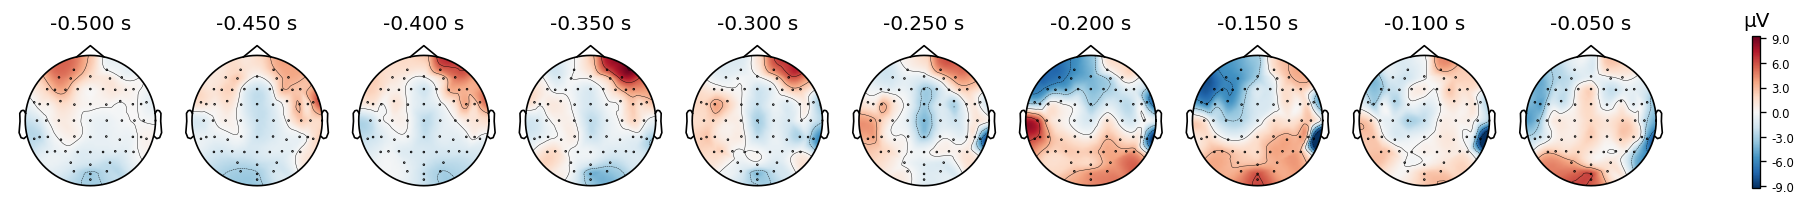

In [ ]:
t = np.arange(-0.5,0,0.05)
e_inspect.average().plot_topomap(times=t)

In [ ]:
e_inspect.filter(1,40).plot_image("C4")

[<Figure size 766.667x575 with 4 Axes>]

# 9. AMICA Rejection
Label components with ICLabel and reject artifact components. 
In this study, we used a conservative approach retaining most of the signal by using a threshold of 85% for "eye blink", "eye movement" or "muscle artifact".

In [ ]:
# -------------------------------------------------------------------------
# AMICA COMPONENT REJECTION
# Loads fitted AMICA objects from 05_amica_proc/ and corresponding epochs
# from 04_epochs/.
# -------------------------------------------------------------------------
wd = Path.cwd()
AMICA_PROC_PATH = wd / "derivatives" / "07_poc_pyprep_asr_amica_proc"
EPOCHS_PATH     = wd / "derivatives" / "06_poc_pyprep_asr_epochs"


# -------------------------------------------------------------------------
# CONFIGURATION
# AMICA_EPOCH_TYPES: "IC", "RS", or None (all epoch types)
# -------------------------------------------------------------------------
AMICA_EPOCH_TYPES = None    # "IC", "RS", or None

# -------------------------------------------------------------------------
# DISCOVER AMICA FILES BASED ON EPOCH TYPE SELECTION
# -------------------------------------------------------------------------
if AMICA_EPOCH_TYPES == "IC":
    amica_pattern = "*IC_*_ica.fif"
elif AMICA_EPOCH_TYPES == "RS":
    amica_pattern = "*RS_*_ica.fif"
elif AMICA_EPOCH_TYPES is None:
    amica_pattern = "*_ica.fif"
else:
    raise ValueError(f"Unknown AMICA_EPOCH_TYPES: '{AMICA_EPOCH_TYPES}'. Choose 'IC', 'RS', or None.")

amica_files = sorted(AMICA_PROC_PATH.rglob(amica_pattern))
print(f"Found {len(amica_files)} fitted ICA objects (AMICA_EPOCH_TYPES='{AMICA_EPOCH_TYPES}')")

### 9.1. Soft rejection
Only reject IC with > 85 % artifact probability (eye, muscle)

In [ ]:
# -------------------------------------------------------------------------
# AMICA COMPONENT REJECTION
# Loads fitted AMICA objects from 05_amica_proc/ and corresponding epochs
# from 04_epochs/. Applies ICLabel classification and excludes
# components based on the selected rejection mode. Cleaned epochs are
# saved to 06_amica_rej/
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# CONFIGURATION
# Two rejection modes:
#   "category" — reject components whose top label matches a category
#                below AND whose confidence exceeds that category's
#                threshold (e.g. eye blink, muscle artifact)
#   "brain"    — keep only components whose top label is "brain" AND
#                confidence exceeds BRAIN_THRESHOLD; reject everything else
# -------------------------------------------------------------------------
REJECTION_MODE = "category"  # "category" or "brain"
REJ_TAG        = "rej85" # e.g. "brain50" or "rej85"

AMICA_REJ_PATH = wd / "derivatives" / f"08a_poc_pyprep_asr_amica_{REJ_TAG}"


# --- Mode: "category" ---
EXCLUDE_CONFIG = {
    "eye blink"       : 0.85,
    "muscle artifact" : 0.85,
    "brain"           : None,
    "heart beat"      : None,
    "line noise"      : None,
    "channel noise"   : None,
    "other"           : None,
}

# --- Mode: "brain" ---
BRAIN_THRESHOLD = 0.50

print(f"Rejection mode : {REJECTION_MODE}")
print(f"Rejection tag  : {REJ_TAG}")

for amica_path in amica_files:
    ses_name = amica_path.parent.parent.name
    sub_name = amica_path.parent.parent.parent.name

    for candidate in ["IC_left", "IC_right", "RS_left", "RS_right"]:
        if candidate in amica_path.name:
            label = candidate
            break
    else:
        print(f"  Could not determine label from filename, skipping : {amica_path.name}")
        continue

    print(f"\nRejecting components : {sub_name} / {ses_name} / {label}")

    try:
        epo_name = amica_path.name.replace("_ica.fif", "-epo.fif")
        epo_path = EPOCHS_PATH / sub_name / ses_name / "eeg" / epo_name

        if not epo_path.exists():
            print(f"  Epoch file not found, skipping : {epo_path.name}")
            continue

        fitcfg_path = amica_path.with_name(amica_path.name.replace("_ica.fif", "_desc-fitcfg.tsv"))
        if not fitcfg_path.exists():
            print(f"  Fit-config file not found, skipping : {fitcfg_path.name}")
            continue
        fitcfg = pd.read_csv(fitcfg_path, sep="\t").iloc[0]

        e = mne.read_epochs(epo_path, preload=True)

        # ICLabel is run on the same cropped, high-pass-filtered view AMICA
        # was fitted on in 5.1 — read back from the sidecar saved at fitting
        # time, so this can never drift out of sync with what was actually
        # fitted (not the full-length epochs).
        e_fit = e.copy().filter(l_freq=fitcfg["hpass"], h_freq=None, picks="eeg")
        e_fit = e_fit.crop(tmax=fitcfg["crop_tmax"])

        ica_mne = mne.preprocessing.read_ica(amica_path)

        ic_labels = label_components(e_fit, ica_mne, method="iclabel")
        labs  = ic_labels["labels"]
        probs = ic_labels["y_pred_proba"]  # top-label confidence per component

        # ---------------------------------------------------------------------
        # IDENTIFY COMPONENTS TO EXCLUDE, BASED ON SELECTED MODE
        # ---------------------------------------------------------------------
        if REJECTION_MODE == "category":
            exclude_idx = []
            for idx, (lab, p) in enumerate(zip(labs, probs)):
                threshold = EXCLUDE_CONFIG.get(lab)
                if threshold is not None and p > threshold:
                    exclude_idx.append(idx)

        elif REJECTION_MODE == "brain":
            exclude_idx = [
                idx for idx, (lab, p) in enumerate(zip(labs, probs))
                if not (lab == "brain" and p > BRAIN_THRESHOLD)
            ]

        else:
            raise ValueError(f"Unknown REJECTION_MODE: '{REJECTION_MODE}'. Choose 'category' or 'brain'.")

        print(f"  Excluding {len(exclude_idx)} / {len(labs)} components:")
        for idx in exclude_idx:
            print(f"    IC{idx:02d} : {labs[idx]} ({probs[idx]:.2f})")

        ep_rej          = e.copy()
        ica_mne.exclude = exclude_idx
        ica_mne.apply(ep_rej)


        output_dir = AMICA_REJ_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        output_name = epo_name.replace("-epo.fif", f"_desc-amicaRej_{REJ_TAG}-epo.fif")
        output_path = output_dir / output_name

        ep_rej.save(output_path, overwrite=True)
        print(f"  Saved : {output_name}")

    except Exception as ex:
        print(f"  Error : {sub_name} / {ses_name} / {label} : {ex}")

    finally:
        for var in ["e", "e_fit", "ica_mne", "ep_rej"]:
            if var in locals():
                del locals()[var]
        gc.collect()

### 9.2. Hard rejection
Only keep ICs with brain probability > 50 % and dipole fit residual variance < 15 %

In [ ]:
# -------------------------------------------------------------------------
# AMICA COMPONENT REJECTION
# Loads fitted AMICA objects from 05_amica_proc/ and corresponding epochs
# from 04_epochs/. Applies ICLabel classification and excludes
# components based on the selected rejection mode. Cleaned epochs are
# saved to 06_amica_rej/
# -------------------------------------------------------------------------


# -------------------------------------------------------------------------
# CONFIGURATION
# Two rejection modes:
#   "category" — reject components whose top label matches a category
#                below AND whose confidence exceeds that category's
#                threshold (e.g. eye blink, muscle artifact)
#   "brain"    — keep only components whose top label is "brain" AND
#                confidence exceeds BRAIN_THRESHOLD; reject everything else
# -------------------------------------------------------------------------
REJECTION_MODE = "brain"  # "category" or "brain"
REJ_TAG        = "brain50" # e.g. "brain50" or "rej85"

AMICA_REJ_PATH = wd / "derivatives" / f"08b_poc_pyprep_asr_amica_{REJ_TAG}"


# --- Mode: "category" ---
EXCLUDE_CONFIG = {
    "eye blink"       : 0.85,
    "muscle artifact" : 0.85,
    "brain"           : None,
    "heart beat"      : None,
    "line noise"      : None,
    "channel noise"   : None,
    "other"           : None,
}

# --- Mode: "brain" ---
BRAIN_THRESHOLD = 0.50   # min brain-label probability
RV_THRESHOLD    = 15.0   # max dipole-fit residual variance (%)

print(f"Rejection mode : {REJECTION_MODE}")
print(f"Rejection tag  : {REJ_TAG}")

for amica_path in amica_files:
    ses_name = amica_path.parent.parent.name
    sub_name = amica_path.parent.parent.parent.name

    for candidate in ["IC_left", "IC_right", "RS_left", "RS_right"]:
        if candidate in amica_path.name:
            label = candidate
            break
    else:
        print(f"  Could not determine label from filename, skipping : {amica_path.name}")
        continue

    print(f"\nRejecting components : {sub_name} / {ses_name} / {label}")

    try:
        epo_name = amica_path.name.replace("_ica.fif", "-epo.fif")
        epo_path = EPOCHS_PATH / sub_name / ses_name / "eeg" / epo_name

        if not epo_path.exists():
            print(f"  Epoch file not found, skipping : {epo_path.name}")
            continue

        dipfit_path = amica_path.with_name(amica_path.name.replace("_ica.fif", "_desc-dipfit_rv.tsv"))
        if not dipfit_path.exists():
            print(f"  Dipole fit file not found, skipping : {dipfit_path.name}")
            continue
        comp_rv = pd.read_csv(dipfit_path, sep="\t")["rv"].values

        fitcfg_path = amica_path.with_name(amica_path.name.replace("_ica.fif", "_desc-fitcfg.tsv"))
        if not fitcfg_path.exists():
            print(f"  Fit-config file not found, skipping : {fitcfg_path.name}")
            continue
        fitcfg = pd.read_csv(fitcfg_path, sep="\t").iloc[0]

        e = mne.read_epochs(epo_path, preload=True)

        # ICLabel is run on the same cropped, high-pass-filtered view AMICA
        # was fitted on in 5.1 — read back from the sidecar saved at fitting
        # time, so this can never drift out of sync with what was actually
        # fitted (not the full-length epochs).
        e_fit = e.copy().filter(l_freq=fitcfg["hpass"], h_freq=None, picks="eeg")
        e_fit = e_fit.crop(tmax=fitcfg["crop_tmax"])

        ica_mne = mne.preprocessing.read_ica(amica_path)

        ic_labels = label_components(e_fit, ica_mne, method="iclabel")
        labs  = ic_labels["labels"]
        probs = ic_labels["y_pred_proba"]  # top-label confidence per component

        # ---------------------------------------------------------------------
        # IDENTIFY COMPONENTS TO EXCLUDE, BASED ON SELECTED MODE
        # ---------------------------------------------------------------------
        if REJECTION_MODE == "category":
            exclude_idx = []
            for idx, (lab, p) in enumerate(zip(labs, probs)):
                threshold = EXCLUDE_CONFIG.get(lab)
                if threshold is not None and p > threshold:
                    exclude_idx.append(idx)

        elif REJECTION_MODE == "brain":
            exclude_idx = [
                idx for idx, (lab, p, rv) in enumerate(zip(labs, probs, comp_rv))
                if not (lab == "brain" and p > BRAIN_THRESHOLD and rv < RV_THRESHOLD)
            ]

        else:
            raise ValueError(f"Unknown REJECTION_MODE: '{REJECTION_MODE}'. Choose 'category' or 'brain'.")

        print(f"  Excluding {len(exclude_idx)} / {len(labs)} components:")
        for idx in exclude_idx:
            print(f"    IC{idx:02d} : {labs[idx]} ({probs[idx]:.2f}), RV={comp_rv[idx]:.1f}%")

        ep_rej          = e.copy()
        ica_mne.exclude = exclude_idx
        ica_mne.apply(ep_rej)

        
        output_dir = AMICA_REJ_PATH / sub_name / ses_name / "eeg"
        output_dir.mkdir(parents=True, exist_ok=True)

        output_name = epo_name.replace("-epo.fif", f"_desc-amicaRej_{REJ_TAG}-epo.fif")
        output_path = output_dir / output_name

        ep_rej.save(output_path, overwrite=True)
        print(f"  Saved : {output_name}")

    except Exception as ex:
        print(f"  Error : {sub_name} / {ses_name} / {label} : {ex}")

    finally:
        for var in ["e", "e_fit", "ica_mne", "ep_rej"]:
            if var in locals():
                del locals()[var]
        gc.collect()

# Summary

This notebook covers the preprocessing steps applied to the concatenated raw EEG data, from raw cleanup through pyPREP/ASR artifact correction, epoching, and AMICA-based component rejection.

1. [Setting channel types and montage](#1-set-channel-types-montage) —
Non-EEG channels were assigned their correct types: `HEOG` and `VEOG` as EOG, `NeckEMG` as EMG, and `x_dir`, `y_dir`, `z_dir` as miscellaneous (acceleration sensors). The standard EasyCap M1 montage was applied to assign electrode locations.

2. [Filtering](#2-filter) —
A bandpass filter of 1–40 Hz was applied.

3. [Restoring the reference channel FCz](#3-restoring-reference-channel-and-average-reference) —
FCz was used as the online reference during recording and is therefore absent from the raw data. It was added back as a zero channel and the data was re-referenced to the average of all EEG channels.

4. [Saving filtered and re-referenced data](#4-save-filtered-and-re-referenced-files) —
Processed files were saved to `derivatives/03_poc_filt_ref/sub-XX/ses-XX/eeg/` following BIDS convention with the descriptor `desc-filtref`.

5. [Channel rejection and interpolation with pyPREP](#5-rejection-and-interpolation-of-channels) —
The pyPREP pipeline was applied using RANSAC-based bad channel detection. Rejected channels were interpolated and a processing log tracking bad channels, interpolated channels, and still-noisy channels was saved per session to `derivatives/04_poc_pyprep/`.

6. [Artifact correction with ASR](#6-artifact-subspace-reconstruction) —
Artifact Subspace Reconstruction (ASR) from *meegkit* was applied to correct for artifacts, fitted and applied to the full session. Processed files were saved to `derivatives/05_poc_pyprep_asr/sub-XX/ses-XX/eeg/` with the descriptor `desc-asr`.

7. [Epoching](#7-epoching) —
Epochs were created for direction cue (RS) and initial ground contact (IC) events, separately for left and right sidecuts. The anticipatory time to response (ATR = IC onset − RS onset) was computed per trial and attached to each epoch as metadata, and trials with excessively long ATR were rejected. A 1–40 Hz bandpass filter was applied again before saving. Processed files were saved to `derivatives/06_poc_pyprep_asr_epochs/sub-XX/ses-XX/eeg/`.

8. [Adaptive mixture independent component analysis (AMICA)](#8-adaptive-mixture-independent-component-analysis) —
pAMICA was fitted per subject and session on a high-pass-filtered (1 Hz) view of the epochs (optionally further cropped per epoch type via `FIT_CROP_TMAX`, currently disabled) to obtain a more stable decomposition. Each component was also fit with a single equivalent dipole against a template (fsaverage) head model, recording its residual variance for use during rejection. Fitted ICA decompositions were saved to `derivatives/07_poc_pyprep_asr_amica_proc/sub-XX/ses-XX/eeg/`.

9. [AMICA Rejection](#9-amica-rejection) —
Components were classified with ICLabel and rejected according to the configured criterion: soft rejection (9.1) excludes components exceeding category-specific thresholds (85% for eye/muscle artifacts), saved to `derivatives/08a_poc_pyprep_asr_amica_rej85/`; hard rejection (9.2) keeps only components with brain probability > 50% and dipole-fit residual variance < 15%, saved to `derivatives/08b_poc_pyprep_asr_amica_brain50/`.